In [37]:
import matplotlib.pyplot as plt
import numpy as np
# import tensorflow_datasets as tfds
import tensorflow as tf
from tensorflow.keras import layers, models

Create CNN

In [38]:

# Input shape: (batch_size, height, width, channels)
input_shape = (28, 28, 1)
inputs = tf.keras.Input(shape=input_shape)

# CNN feature extractor
x = layers.Conv2D(32, (3,3), padding='same', activation='relu')(inputs)
x = layers.MaxPooling2D(pool_size=(2,2))(x)    # (14, 14, 32)
x = layers.Conv2D(64, (3,3), padding='same', activation='relu')(x)
x = layers.MaxPooling2D(pool_size=(2,2))(x)    # (7, 7, 64)

# Reshape CNN output to (sequence_length, feature_dim)
# sequence_length = width * height slices, feature_dim = channels
# Here we treat width (7) as the time dimension
features = layers.Reshape((7, 7*64))(x)        # (batch, 7 steps, 448 features)

Create BiLSTM

In [39]:
num_classes = 10  # Change to your actual number of classes

# BiLSTM layer
lstm_out = layers.Bidirectional(layers.LSTM(128, return_sequences=True))(features)
# outputs = layers.TimeDistributed(layers.Dense(10, activation='softmax'))(lstm_out)
outputs = layers.Dense(num_classes)(lstm_out)


Create Model

In [ ]:
# Model for training (inputs and logits)
model = models.Model(inputs, outputs)
model.summary()

def ctc_loss(y_true, y_pred):
    # y_true: shape (batch, max_label_length)
    # y_pred: shape (batch, time_steps, num_classes)
    batch_size = tf.shape(y_pred)[0]
    input_length = tf.fill([batch_size, 1], tf.shape(y_pred)[1])
    label_length = tf.math.count_nonzero(y_true, axis=-1, keepdims=True)
    return tf.keras.backend.ctc_batch_cost(y_true, y_pred, input_length, label_length)

# Compile with CTC loss
model.compile(optimizer=tf.keras.optimizers.Adam(), loss=ctc_loss, metrics=['accuracy'])


Model: "functional_40"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_2 (Reshape)             │ (None, 7, 448)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (None, 7, 256)         │       590,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7, 10)          │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 612,234 (2.34 MB)

 Trainable params: 612,234 (2.34 MB)

 Non-trainable params: 0 (0.00 B)

Export MINST Database

In [71]:
mnist = tf.keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()

See outputs from layers

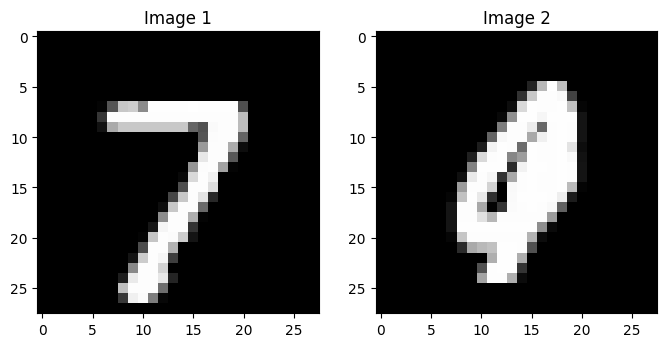

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
CNN features shape: (2, 7, 7, 64)


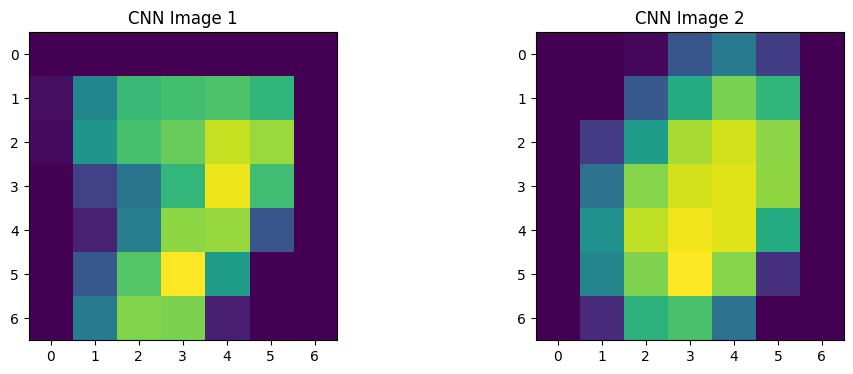

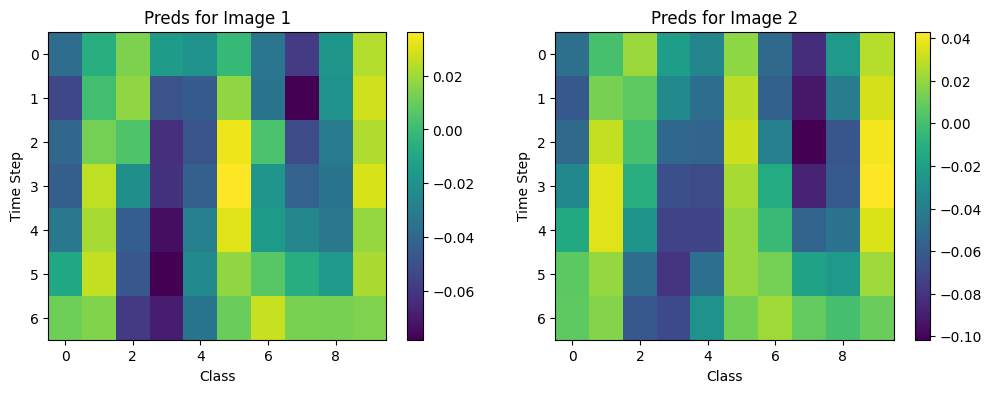

Decoded sequences: [array([[ 0,  6, -1, -1, -1, -1, -1],
       [ 0,  6, -1, -1, -1, -1, -1]])]
Log probs: [[nan]
 [nan]]


In [72]:
# Select 2 random images from x_train and reshape to (28, 28, 1)
idx = np.random.choice(x_train.shape[0], 2, replace=False)
dummy_images = x_train[idx].astype(np.float32) / 255.0
dummy_images = np.expand_dims(dummy_images, -1)

# Visualize dummy images
fig, axes = plt.subplots(1, dummy_images.shape[0], figsize=(8, 4))
for i in range(dummy_images.shape[0]):
    axes[i].imshow(dummy_images[i, :, :, 0], cmap='gray')
    axes[i].set_title(f"Image {i+1}")
plt.show()


# Get CNN features for dummy_images
cnn_model = models.Model(inputs, x)
cnn_features = cnn_model.predict(dummy_images)

print("CNN features shape:", cnn_features.shape)
fig, axes = plt.subplots(1, cnn_features.shape[0], figsize=(12, 4))
for i in range(cnn_features.shape[0]):
    # Show the mean across channels for visualization
    axes[i].imshow(np.mean(cnn_features[i], axis=-1), cmap='viridis')
    axes[i].set_title(f"CNN Image {i+1}")


# Visualize preds as heatmaps for each image
preds = model(dummy_images)
fig, axes = plt.subplots(1, preds.shape[0], figsize=(12, 4))
for i in range(preds.shape[0]):
    im = axes[i].imshow(preds[i], aspect='auto', cmap='viridis')
    axes[i].set_title(f"Preds for Image {i+1}")
    axes[i].set_xlabel("Class")
    axes[i].set_ylabel("Time Step")
    fig.colorbar(im, ax=axes[i])
plt.show()

y_pred = preds
decoded, log_prob = tf.keras.backend.ctc_decode(
    y_pred, input_length=np.ones(y_pred.shape[0])*y_pred.shape[1], greedy=True
)

# Convert decoded tensors to numpy arrays
decoded = [d.numpy() for d in decoded]
log_prob = log_prob.numpy()

print("Decoded sequences:", decoded)
print("Log probs:", log_prob)